## `TP Deep Clustering` 

L'objectif de ce TP consiste à créer un modèle constitué de plusieurs parties :

- Un auto-codeur, pré-entraîné pour apprendre la représentation condensée initiale des jeux de données non étiquetés.
- Une couche de clustering empilée sur l'encodeur pour affecter la sortie de l'encodeur à un cluster. Les poids de la couche de clustering sont initialisés avec les centres de cluster de K-Means basés sur l'évaluation actuelle.
- Entraîner le modèle de clustering pour affiner la couche de clustering et le codeur conjointement.


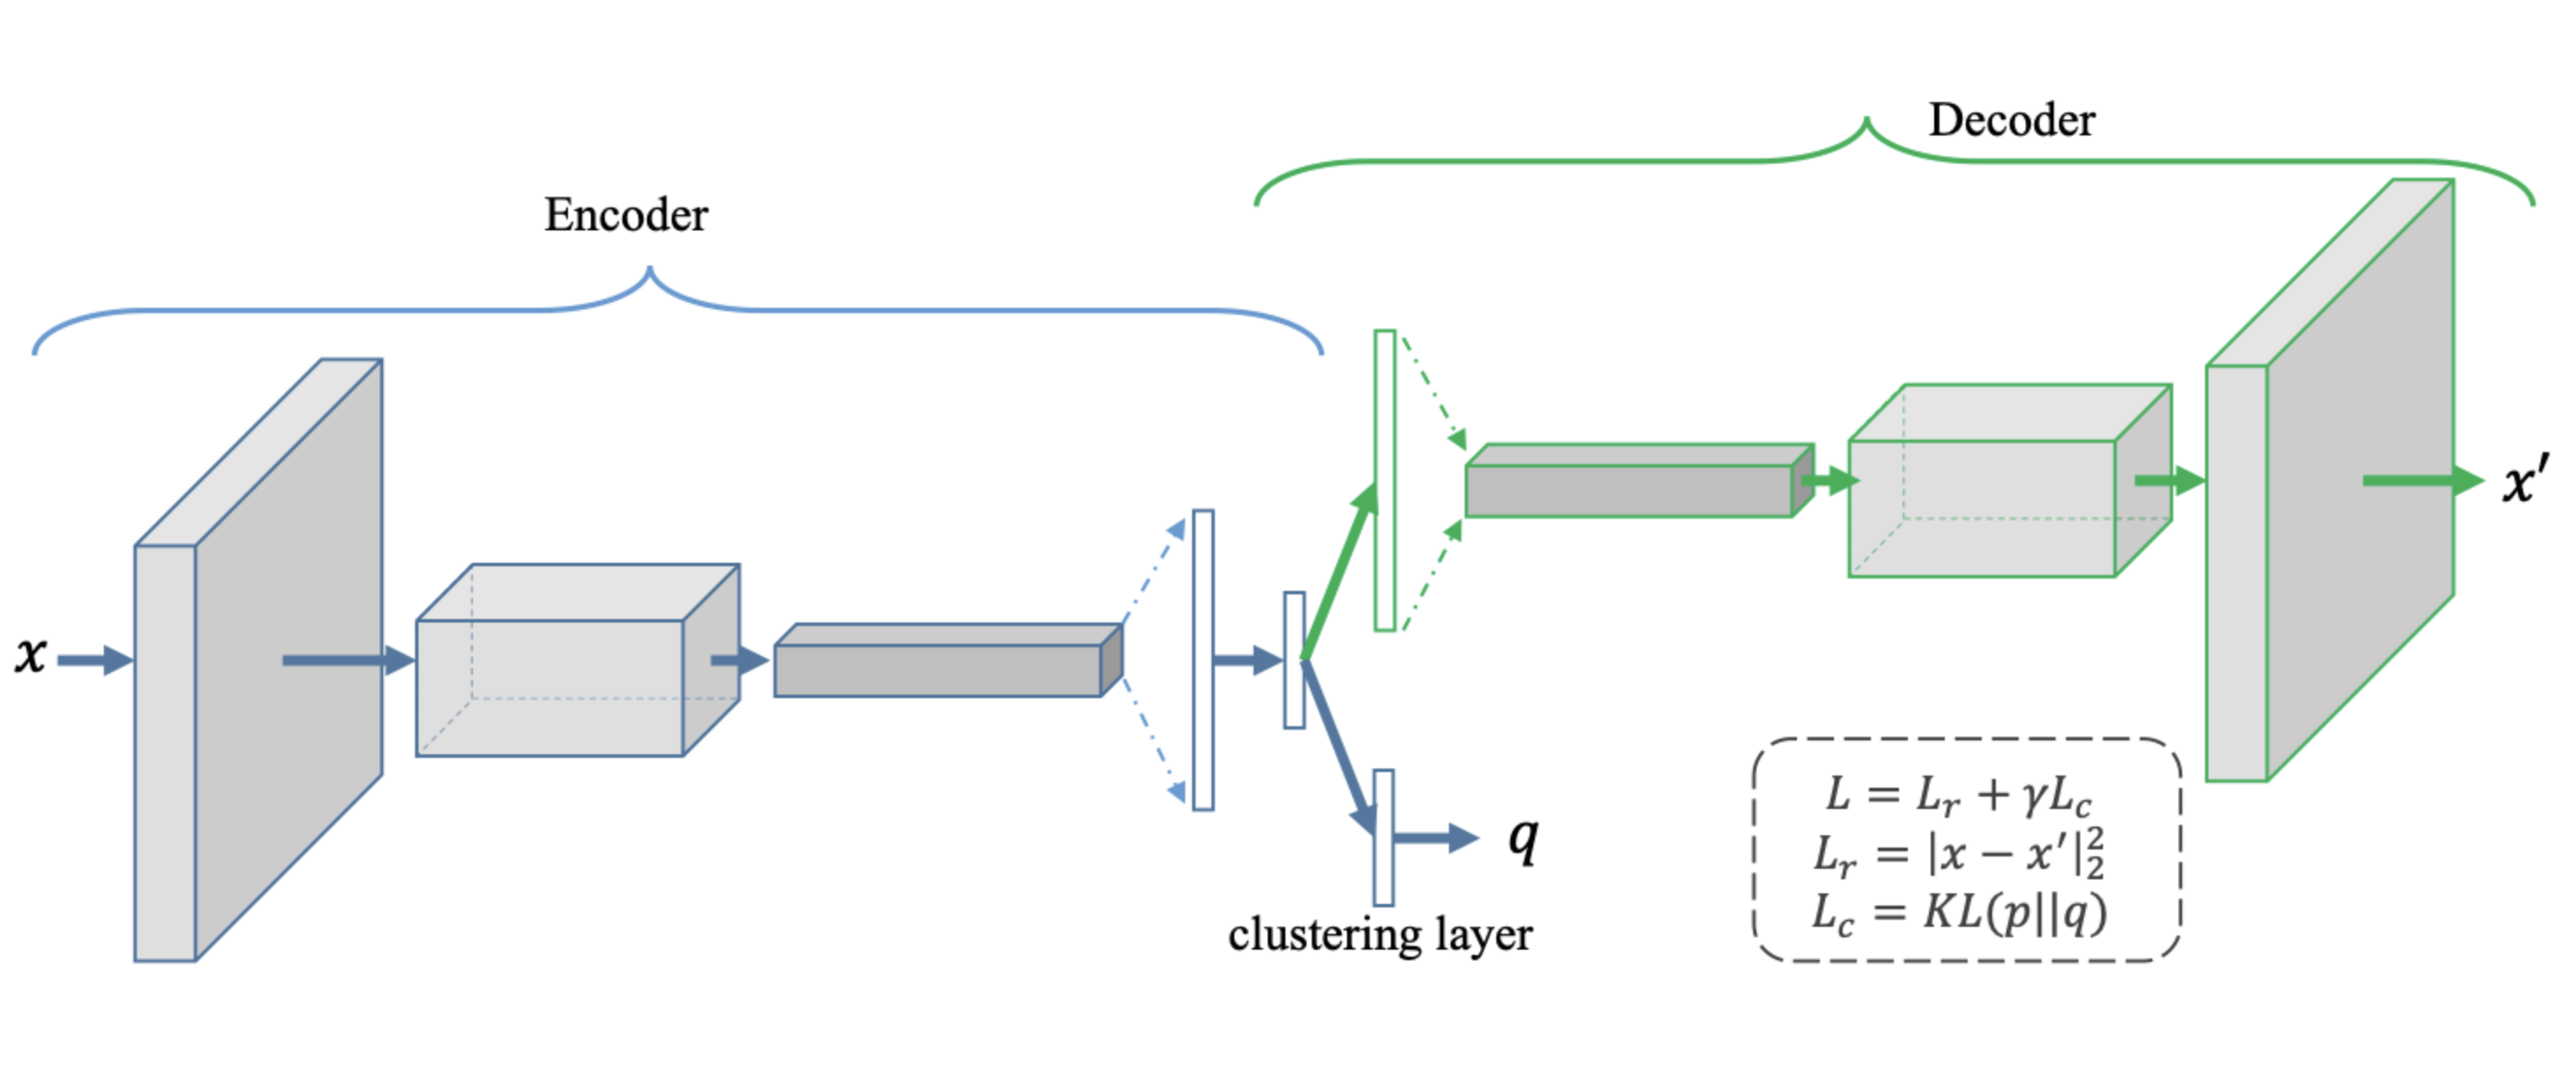

In [4]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/DeepClustering.png",width=700))

`L’encoder + k‑means en non supervisé :`
 - Pipeline non supervisé encoder + k‑means
 - Pré‑entraînement non supervisé de l’encoder

`Autoencoder conv :` 
 - apprend à reconstruire l’image, donc l’espace latent z se structure sans labels.
 - Ou méthode type DEC / Deep Embedded K‑Means où l’encoder est entraîné avec une loss qui dépend des clusters eux‑mêmes (distribution cible, KL, etc.).

`Clustering dans l'espace latent`
 - on passe les images dans l’encoder, 
 - récupères les embeddings $z_i$, 
 - on appliques k‑means sur les ${z_i}$.

`Les indices de clusters de k‑means sont tes pseudo‑labels non supervisés`.
- Option raffinement (deep embedded clustering)
 - On ré‑entraînes l’encoder en forçant les embeddings à se rapprocher des centres de leurs clusters (loss basée sur la KL entre assignations et une distribution cible plus « piquée »).

Les seules « étiquettes » sont produites par k‑means à partir des features apprises, pas par un annotateur humain.

In [20]:
from time import time
import numpy as np
import keras.backend as K # type: ignore
from tensorflow.keras.layers import Layer, InputSpec, UpSampling2D, Flatten, Reshape, Conv2DTranspose  # type: ignore
from tensorflow.keras.models import Model  # type: ignore
from tensorflow.keras.initializers import VarianceScaling  # type: ignore
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

### `Chargement des données`

In [21]:
from keras.datasets import mnist  # type: ignore
from keras.datasets import fashion_mnist  # type: ignore à tester, + complexe que l'ensemble mnist 

import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST/Fashion mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"x_train.shape : {x_train.shape}")
x_trainIm = x_train.astype('float32') / 255.
x_testIm = x_test.astype('float32') / 255.
print(f"x_trainIm.shape : {x_trainIm.shape}")

x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))
print(f"x_train_rshp.shape : {x_train_rshp.shape}")

x_train.shape : (60000, 28, 28)
x_trainIm.shape : (60000, 28, 28)
x_train_rshp.shape : (60000, 784)


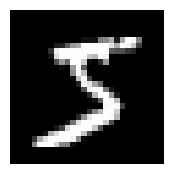

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()

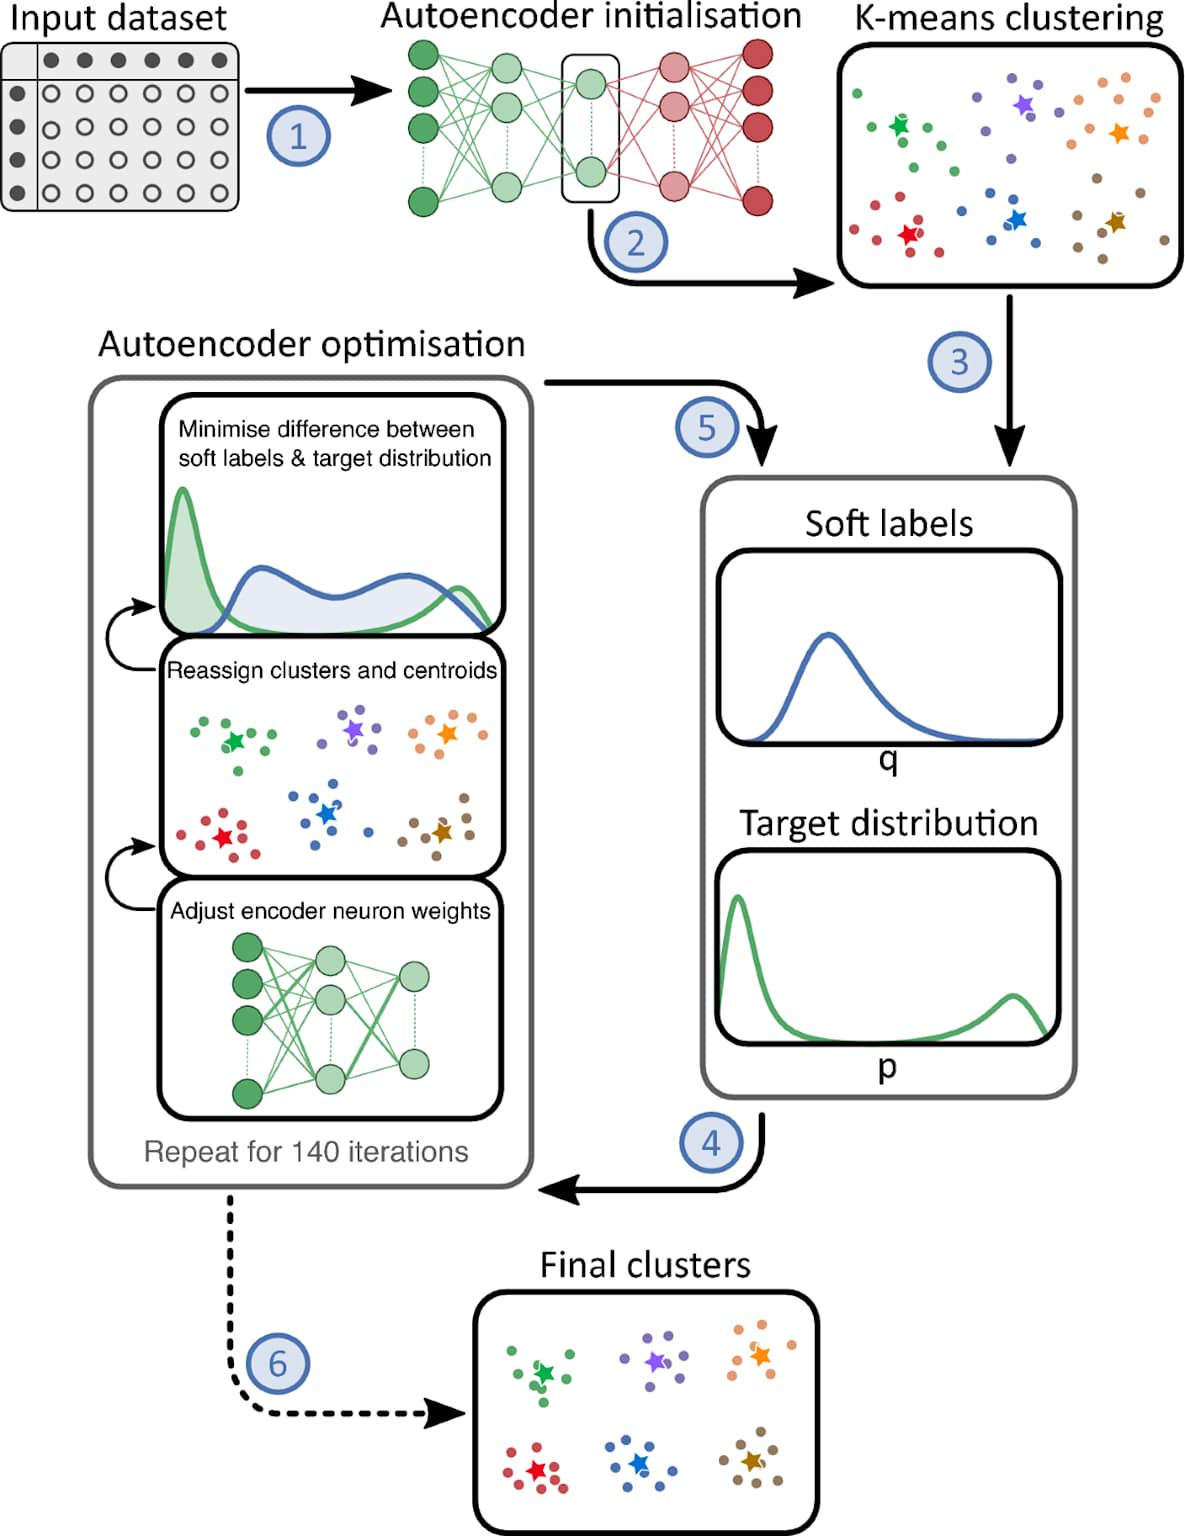

In [23]:
from IPython.display import Image, display
display(Image("M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/otoncdrKmnsClstrg.jpg",width=400))

### `Baseline par clustering classique par kmeans`

`y_pred_kmeans` 
- vecteur d’entiers de taille (n_samples,) 
- contient l’indice du cluster auquel KMeans a affecté chaque sample (0, 1, ..., n_clusters-1)
- il n’y a pas de correspondance directe entre indice de cluster et indice de classe. 
- les indices de KMeans sont arbitraires

In [36]:
# Nombre de classes à trouver
n_clusters=10
# nombre de chiffres
n_digits = len(np.unique(y_test))
print(f"n_digits : {n_digits}")
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
print(f"y_pred_kmeans.shape : {y_pred_kmeans.shape}")
print(f"y_pred_kmeans : {y_pred_kmeans}")

n_digits : 10
y_pred_kmeans.shape : (60000,)
y_pred_kmeans : [2 0 1 ... 8 5 3]


`Ecrire acc = accuracy_score(y_pred_kmeans, y_train) n’a pas de sens.`

Les options cohérentes sont donc :
 - remapping cluster → classe (via matrice de confusion + Hungarian) puis calculer l’accuracy;
 - utiliser des métriques de clustering (Adjusted Rand Index, NMI, etc.) plutôt qu’une accuracy.

In [28]:
# Score de performance
acc = accuracy_score(y_pred_kmeans, y_train)
print(f"Accuracy KMeans (fit_predict) : {acc:.4f}")

Accuracy KMeans (fit_predict) : 0.2238


### `Attribution des étiquettes de cluster`

 - La classification K-means est une méthode d'apprentissage automatique non supervisée
 - Les étiquettes KMeans référence la classification attribué à chaque élément et non à l'entier cible réel
 - Les fonctions ci-dessous permettent de prédir à quel classe correspond à chaque cluster

__`Ce que signifie cet appel`__
 - y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans.
 - y_train sont les vraies étiquettes (supervisées) de tes données d’entraînement.
 - `retrieve_info(cluster_labels, y_train)`
   - calcule, pour chaque cluster, la classe majoritaire dans ce cluster 
   - renvoie un tableau reference_labels qui fait la correspondance
   - reference_labels[i] = classe majoritaire parmi les points du cluster i.

In [37]:
def retrieve_info(cluster_labels, y_train):
    cluster_labels = np.asarray(cluster_labels).ravel()
    y_train = np.asarray(y_train).ravel()

    n_clusters = len(np.unique(cluster_labels))
    reference_labels = np.zeros(n_clusters, dtype=int)   # <-- 1D

    print(f"cluster_labels : {cluster_labels.shape}")
    for i in range(n_clusters):
        index = (cluster_labels == i)
        num = np.bincount(y_train[index]).argmax()
        reference_labels[i] = num
    print(f"index.shape : {index.shape}")    
    return reference_labels


- `La fonction correspondance effectue le mapping numéro de cluster classe réel`
- `Pour chaque prédiction cluster associé à un élement, la classe correspondante`

In [ ]:
def correspondance(y_pred_kmeans,y_train):
  # Correspondance entre la partition et les classes de la vérité terrain
  # y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans, 
  # reference_labels[i] = classe majoritaire parmi les points du cluster i.
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels

`Obtenir un score de performance`
- Après la correspondance clusters → classes, 
- Utiliser _reference_labels_ pour transformer les labels de clusters en labels de classes, 
- puis calculer une accuracy classique.

In [32]:
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
print(f"y_train_pred.shape : {y_train_pred.shape}")

# score de performance sur l'apprentissage
score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy KMeans (apprentissage) : {score:.4f}")

cluster_labels : (60000,)
index.shape : (60000,)
y_train_pred.shape : (60000,)
Accuracy KMeans (apprentissage) : 0.5502


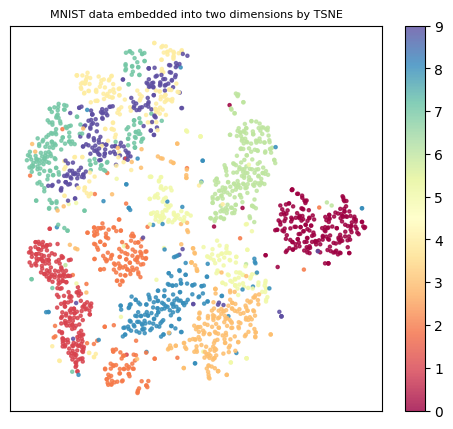

In [75]:
# Affichage des données 
count=2000
ListeData = np.random.choice(len(x_test), count)
inputs = x_train[ListeData]
classes = y_train[ListeData]

# Appliquer une réduction de données en 2D via la TSNE
embedTSNE = TSNE(n_components=2).fit_transform((inputs))

color = classes.astype(int) # type: ignore
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedTSNE[:, 0], embedTSNE[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title("MNIST data embedded into two dimensions by TSNE", fontsize=8)
plt.colorbar()
plt.show()

# Autoencodeur classique à définir 

In [77]:
from tensorflow.keras.models import Sequential # type: ignore 
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense # type: ignore
 
autoencoder = Sequential([
    # Entrée 28x28x1
    Input(shape=(28, 28, 1)),
    Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2),activation="relu", padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2), padding="same"),
    Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2),activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2), padding="same"),
    Conv2D(filters=128, kernel_size=(3, 3), strides=(2, 2),activation="relu", padding="same"),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

In [81]:
# Ajouter la dimension canal : (N, 28, 28, 1)
x_train_oh = np.expand_dims(x_trainIm, axis=-1)
x_test_oh  = np.expand_dims(x_testIm, axis=-1)

print(f"x_train_oh.shape : {x_train_oh.shape} x_train.shape : {x_train.shape}")  # (60000, 28, 28, 1)
print(f"x_test_oh.shape : {x_test_oh.shape} x_test.shape : {x_test.shape}")  # (10000, 28, 28, 1)

x_train_oh.shape : (60000, 28, 28, 1) x_train.shape : (60000, 784)
x_test_oh.shape : (10000, 28, 28, 1) x_test.shape : (10000, 784)


In [83]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   # labels one-hot
    metrics=["accuracy"],
)

# Entraînement de l'autoencodeur 

In [94]:
# Entraînement de l'autoencodeur 
autoencoder.fit(x_train_oh, x_trainIm,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_oh, x_testIm))

Epoch 1/25


ValueError: Dimensions must be equal, but are 28 and 10 for '{{node compile_loss/mse/sub}} = Sub[T=DT_FLOAT](data_1, sequential_8_1/dense_17_1/Softmax)' with input shapes: [?,28,28], [?,10].

In [ ]:
# Encoder et décoder quelques chiffres de l'ensemble test


In [ ]:
n = 20  # Combien de chiffres nous allons afficher

# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# À COMPLÉTER

In [ ]:
# Affichage de l'espace latent par réduction de dimension 
count=2000
inputs = x_train[ListeData]
classes = y_train[ListeData]

# Récupération des données dans l'espace latent


# Réduction de dimension 2D par ACP


# Réduction de dimension 2D par la TSNE


# Affichage de l'espace latent par ACP et TSNE


In [ ]:
# Classification par kmeans de l'espace latent sur l'ensemble d'apprentissage

# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Affichage
inputsTrain = x_train
classesTrain = y_train


# Kmeans sur base d'apprentissage

# Score de performance sur l'apprentissage

print("Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent")


## Couche de clustering 
maintient les centres de cluster $\mu_j$ comme poids entraînables et projette chaque point intégré $z_i$ en soft label $q_i$ par la distribution $t$ de Student:
$$q_{ij}=\frac{(1+\|z_i-\mu_j\|^2)^{-1}}{\sum_j(1+\|z_i-\mu_j\|^2)^{-1}}$$
où $q_{ij}$ est la $j$ième entrée de $q_i$, représentant la probabilité d'appartenance de $z_i$ au cluster $j$.

In [ ]:
class ClusteringLayer(Layer):
    """
    La couche de classification convertit l'échantillon d'entrée (caractéristique) en une étiquette souple, c'est-à-dire un vecteur qui représente la probabilité d'appartenance de l'échantillon à chaque groupe.
    probabilité d'appartenance de l'échantillon à chaque cluster. La probabilité est calculée avec la distribution t de student.
    # Exemple
    ```
        model.add(ClusteringLayer(n_clusters=10))
    ```
    # Arguments
        n_clusters : nombre de clusters.
        weights : liste de tableaux Numpy de forme `(n_clusters, n_features)` qui représente les centres de clusters initiaux.
        alpha : paramètre de la distribution t de Student. La valeur par défaut est 1.0.
    # Forme de l'entrée
        Tenseur 2D avec la forme : `(n_samples, n_features)`.
    # Forme en sortie
        Tenseur 2D avec forme : `(n_samples, n_clusters)`.
    """


    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=K.floatx(), shape=(None, input_dim))
        self.clusters = self.add_weight(shape=(self.n_clusters, input_dim), initializer='glorot_uniform', name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    def call(self, inputs, **kwargs):
      """ Distribution t de student, la même que celle utilisée dans l'algorithme t-SNE.
                 q_ij = 1/(1+dist(x_i, u_j)^2), puis normalisation.
        Arguments :
            inputs : la variable contenant les données, shape=(n_samples, n_features)
        Retourne :
            q : la distribution t de student, ou des étiquettes souples pour chaque échantillon. shape=(n_samples, n_clusters)
        """
      q = 1.0 / (1.0 + (K.sum(K.square(K.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
      q **= (self.alpha + 1.0) / 2.0
      q = K.transpose(K.transpose(q) / K.sum(q, axis=1))
      return q

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


Définition de la distribution $P$ cible définie comme
$$p_{ij}=\frac{q_{ij}^2/\sum_i q_{ij}}{\sum_j (q_{ij}^2/\sum_i q_{ij})}.$$
où $p_{ij}$ est la $j$ième entrée de $p_i$ représentant la probabilité d'appartenance de la donnée $i$ la classe $j$

In [ ]:
# Calcul de la distribution cible
def target_distribution(q):
  # à compléter
    return 0

In [ ]:
# Configuration de la couche de clustering
clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
model = Model(inputs=encoder.input, outputs=clustering_layer)

model.compile(optimizer="Adam", loss='kld')

# Entrainement du modèle avec la couche de clustering

In [ ]:
# paramètres à fixer
loss = 0
index = 0
maxiter =4000
update_interval = 140
batch_size=128
index_array = np.arange(x_train.shape[0])
tol = 0.005 # seuil pour critère d'arrêt

In [ ]:
#Initialisation Kmeans
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
y_pred = kmeans.fit_predict(encoder.predict(x_train))

# récupération des centres de clusters   
y_pred_last = np.copy(y_pred)
model.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])

for ite in range(int(maxiter)):
    if ite % update_interval == 0:
        q = model.predict(x_train, verbose=0)
        p = target_distribution(q)  # mise à jour de la distribution cible p 

        # evaluation de la performance du clustering 
        y_pred = q.argmax(1)
        if y_train is not None: 
            y_pred=correspondance(y_pred,y_train)
            acc = np.round(accuracy_score(y_train, y_pred), 5)
            loss = np.round(loss, 5)
            print('(Iter , acc)  ',(ite, acc), ' ; loss=', loss)

        # check stop criterion - model convergence
        delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
        y_pred_last = np.copy(y_pred)
        if ite > 0 and delta_label < tol:
            print('delta_label ', delta_label, '< tol ', tol)
            print('Reached tolerance threshold. Stopping training.')
            break
    idx = index_array[index * batch_size: min((index+1) * batch_size, x_train.shape[0])]
    loss = model.train_on_batch(x=x_train[idx], y=p[idx])
    index = index + 1 if (index + 1) * batch_size <= x_train.shape[0] else 0

In [ ]:
# Affichage de l'impact de cette couche clustering 

inputs = x_train[ListeData]
classes = y_train[ListeData]

# TSNE sur espace latent avec kmeans
coordsAC_V2 = encoder.predict(inputs)
coordsTSNE_V2 = TSNE(n_components=2).fit_transform(coordsAC_V2.reshape(count, -1))


fig2= plt.figure(figsize=(30, 10))
ax2=plt.subplot(1,3,1)
ax2.set_title("TSNE sur MNIST")
plt.scatter(coordsTSNE[:, 0], coordsTSNE[:, 1], c=classes,cmap='Paired')
plt.colorbar()


ax2 = plt.subplot(1,3,2)
ax2.set_title("tSNE sur espace latent")
plt.scatter(coordsTSNE_AC[:, 0], coordsTSNE_AC[:, 1], c=classes,cmap='Paired')
plt.colorbar()



ax2 = plt.subplot(1,3,3)
ax2.set_title("tSNE après clustering sur espace latent")
plt.scatter(coordsTSNE_V2[:, 0], coordsTSNE_V2[:, 1], c=classes,cmap='Paired')
plt.colorbar()

# Passer à la version convolutive de l'autoencodeur